# Unit 0, Lesson 1: Foundations

We start by following the first lesson of [IBMs Use a Quantum Computer Today](https://quantum.cloud.ibm.com/learning/en/courses/use-a-qc-today/build-and-run-your-first-quantum-program)

Publication note: explanations and execution settings received AI-assisted editorial corrections. All experiments below use local simulators, not quantum hardware.

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager


Now, we create the bell state in a 2-register circuit, demonstrating entanglement of 2 qubits

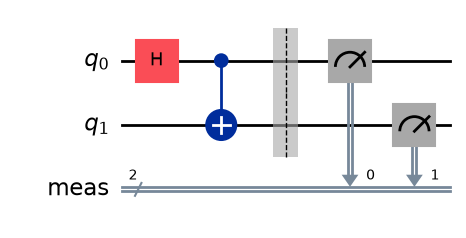

In [2]:
bell = QuantumCircuit(2)
bell.h(0)
bell.cx(0, 1)
bell.measure_all()

bell.draw("mpl")

> Prediction before execution:
> The circuit applies a Hadamard gate to qubit 0 and then uses qubit 0 to control an X gate on qubit 1.
>
> 1. Which two-bit strings do you expect to observe?
> 2. Which strings should never occur in the ideal simulation?
> 3. Do you expect exactly half of the finite shots to give each permitted result? Why or why not?

1) We expect to observe 00 or 11. Since the first gate has entered a superposition of 0 and 1, or $|\psi\rangle = \frac{|0\rangle + |1\rangle}{\sqrt{2}}$, and the second 'not' gate, or X gate, sets the qubit to 1 iff the first is 1, then we can either get 00 or 11.
2) Ideally, 01 and 10 never occur
3) Each permitted result has probability $|1/\sqrt{2}|^2=1/2$, but a finite sample need not split exactly in half. The count of `00` results follows a binomial law.

In [3]:
def run_circuit(circuit: QuantumCircuit, backend: AerSimulator, shots: int = 1024, seed: int = 42) -> dict[str, float]:
    # Transpile to the simulator's supported operations, then sample locally.
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1, seed_transpiler=seed)
    isa_circuit = pm.run(circuit)
    counts = backend.run(isa_circuit, shots=shots, seed_simulator=seed).result().get_counts()
    assert sum(counts.values()) == shots
    return {bits: count / shots for bits, count in counts.items()}


In [4]:
# Both simulators are ideal here: no noise model has been supplied.
# "automatic" chooses a simulation method; it does not add device noise.
automatic_backend = AerSimulator(method='automatic')
statevector_backend = AerSimulator(method='statevector')

# Investigating available devices, default is 'CPU'
print(automatic_backend.available_devices())

('CPU',)


In [5]:
results = run_circuit(bell, automatic_backend)
results

{'11': 0.4912109375, '00': 0.5087890625}

In [6]:
results_sv = run_circuit(bell, statevector_backend)
results_sv

{'00': 0.513671875, '11': 0.486328125}

In [7]:
results_32 = run_circuit(bell, statevector_backend, shots=32)
results_32

{'11': 0.46875, '00': 0.53125}

## Testing a Noise Model

I additionally experiment here with [Noise Models](https://qiskit.github.io/qiskit-aer/apidocs/aer_noise.html) from the aer documentation

In [8]:
from qiskit_aer.noise import NoiseModel

# Fake device data is supplied by the separate qiskit-ibm-runtime package.
from qiskit_ibm_runtime.fake_provider import FakeVigoV2

backend_for_noise = FakeVigoV2()
noise_model = NoiseModel.from_backend(backend_for_noise)

# A coupling map is the qubit connectivity graph. This can be used in transpilation
coupling_map = backend_for_noise.configuration().coupling_map
# Basis gates are the native operations permitted on the device, again used for transpiler.
# Some gates are decomposed into simpler gates in the basis
basis_gates = noise_model.basis_gates

noisy_backend = AerSimulator(
    noise_model=noise_model, 
    basis_gates=basis_gates, 
    coupling_map=coupling_map
)

results_noisy = run_circuit(bell, noisy_backend, shots=10000)
results_noisy

{'01': 0.0487, '10': 0.0489, '00': 0.4467, '11': 0.4557}

> Live exit questions
> 1. What random object does one shot return, and what is its support?
> 2. Why are amplitudes $1/\sqrt2$ while probabilities are $1/2$?
> 3. What evidence from the joint law disproves independence?
> 4. What changes when the shot count increases, and what does not change?

1. One shot is a pair of bits, and the sample space is $\Omega = \{(0,0),(0,1),(1,0),(1,1)\}$ The theoretical support is $\{(0,0),(1,1)\}$, but as we see from experiments, it may be all of $\Omega$
2. The probabilities themselves are constructed from the norm of the quantum state's magnitudes, since we have both real and imaginary parts. For a qubit, we have the Born rule such that when $|\phi\rangle = \alpha |0\rangle + \beta|1\rangle,$, then $|\alpha|^2 + |\beta|^2 = 1$. Structurally, amplitudes must add to allow for interference, but probabilities must be positive and normalized.
3. We can demonstrate that for random variables for individual qubits $B_0$ and $B_1$, that $P(B_0 = 0, B_1 = 1) = 0 \ne \frac{1}{4} = P(B_0 = 0)P(B_1 = 1)$.
4. The total number of successes for random variables, such as $B_0 = 1$ or $B_0 = 1, B_1 = 1$, changes since the number of events changes. The underlying distribution, including noise, does not change.

> Ten-minute closure before Lesson 02
> 1. Why can two ideal simulator runs return different proportions even though both represent the same Bell-state law?
> 2. Why do `01` and `10` in the fake-device run indicate modeled error, while a 55/45 split between `00` and `11` does not?

1. Each shot samples the same probability law. For $n$ independent ideal shots, the number of `00` results has distribution $\mathrm{Bin}(n,1/2)$; the observed fraction varies around $1/2$. Its standard deviation is $1/(2\sqrt{n})$, and a normal approximation becomes useful for large $n$.
2. Ideal computational-basis measurements of this Bell state only produce `00` and `11`. Nonzero `01` or `10` frequencies in the fake-device simulation arise from the configured noise model, which can include gate and readout errors. They do not identify one particular faulty gate. Unequal counts of `00` and `11` in a finite ideal sample are sampling variation; repeated deviations would require a statistical check before attributing them to a systematic error.
